In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utility import *
from tools import *
from maps import *
from scipy.stats import linregress
from scipy.ndimage import maximum_filter, binary_dilation
from scipy.spatial.distance import cdist
from itertools import combinations

In [2]:
# Load the Data's directory.
datadir = 'C:/Users/txu245/Desktop/26-02-24/01_01_03.zda'

# Load the Tool Packages.
DataLoader = DataLoader(datadir)
Tools = Tools()
Maps = Maps()

In [3]:
# Parameters setting up.
index = np.linspace(0, 499.5, 1000)
basePt = 190
skipPt = 60
startPt = 190
numPt = 150

# Data Preprocessing.
Data = DataLoader.get_data()
Data = Tools.Polynomial(startPt=basePt, numPt=skipPt, Data=Data)
Rli = DataLoader.get_rli()
Data = Tools.Rli_Division(Rli=Rli, Data=Data)
Data = Tools.T_filter(Data=Data)
Data = Tools.S_filter(sigma=1, Data=Data)
Data_ave = np.mean(Data, axis=0)

# SNR Map. (Without Normalization)
snr_map = Maps.SNR_Map(startPt=startPt, numPt=numPt, Data=Data)

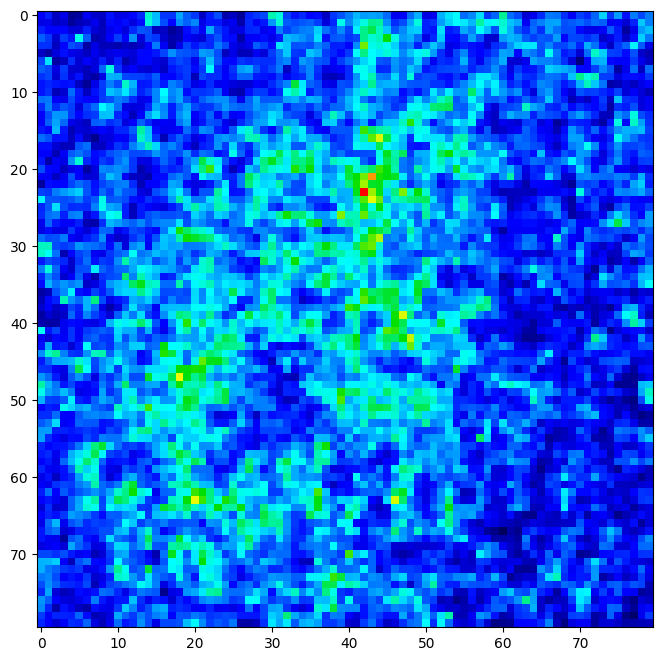

In [4]:
plt.figure(figsize=(8, 8))
plt.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=Maps.colorbar())
plt.show()

In [5]:
def is_connected_4(pixels):
    
    pixels = set(pixels)
    stack = [next(iter(pixels))]
    visited = set()

    while stack:
        r,c = stack.pop()
        visited.add((r,c))

        neighbors = [(r+1,c),(r-1,c),(r,c+1),(r,c-1)]

        for n in neighbors:
            if n in pixels and n not in visited:
                stack.append(n)

    return visited == pixels

In [6]:
coords = [(dr, dc) for dr in [-1,0,1] for dc in [-1,0,1]]

center = (0,0)

roi_shapes = []

for k in range(1,10):

    for comb in combinations(coords, k):

        if center not in comb:
            continue
        else:
            roi_shapes.append(comb)
            
print("number of ROI shapes:", len(roi_shapes))

number of ROI shapes: 256


In [7]:
def compute_snr(trace):

    signal = np.max(trace[startPt:(startPt+numPt)])
    noise = np.std(trace[10:60], ddof=1)

    return signal / noise

In [8]:
def optimize_pixel(traces, r, c, roi_shapes):

    best_snr = -np.inf
    best_shape = None

    for shape in roi_shapes:

        pixels = [(r+dr, c+dc) for dr,dc in shape]

        selected = np.array([traces[x,y] for x,y in pixels])

        avg_trace = selected.mean(axis=0)

        snr = compute_snr(avg_trace)

        if snr > best_snr:

            best_snr = snr
            best_shape = pixels

    return best_shape, best_snr

In [9]:
def optimize_map(traces, roi_shapes):

    H, W, T = traces.shape

    best_snrs = np.zeros((H,W))
    best_rois = [[None]*W for _ in range(H)]

    for r in range(1,H-1):
        for c in range(1,W-1):

            roi, snr = optimize_pixel(traces, r, c, roi_shapes)

            best_rois[r][c] = roi
            best_snrs[r,c] = snr

    return best_rois, best_snrs

In [10]:
rois, snrs = optimize_map(Data_ave, roi_shapes)

In [11]:
candidates = []

for i in range(80):
    for j in range(80):
        candidates.append([int(i), int(j), snrs[i][j], rois[i][j]])
        
third_values = [x[2] for x in candidates]
cutoff = np.percentile(third_values, 95)

candidates = [x for x in candidates if x[2] >= cutoff]

In [12]:
# Select those 3x3 areas without overlapping.
def select_non_overlapping(candidates, snr_map):
    candidates = sorted(candidates, key=lambda x: x[2], reverse=True)

    selected = []
    occupied = np.zeros_like(snr_map, dtype=bool)

    for r, c, snr_value, comb in candidates:
        r = int(r)
        c = int(c)
        if not np.any(occupied[r-1:r+2, c-1:c+2]):
            selected.append([r, c])
            occupied[r-1:r+2, c-1:c+2] = True

    return selected

# Implement.
selected = select_non_overlapping(candidates, snr_map)
identified_map = np.zeros_like(snr_map, dtype=int)

for coor in selected:
    identified_map[coor[0]][coor[1]] = 1

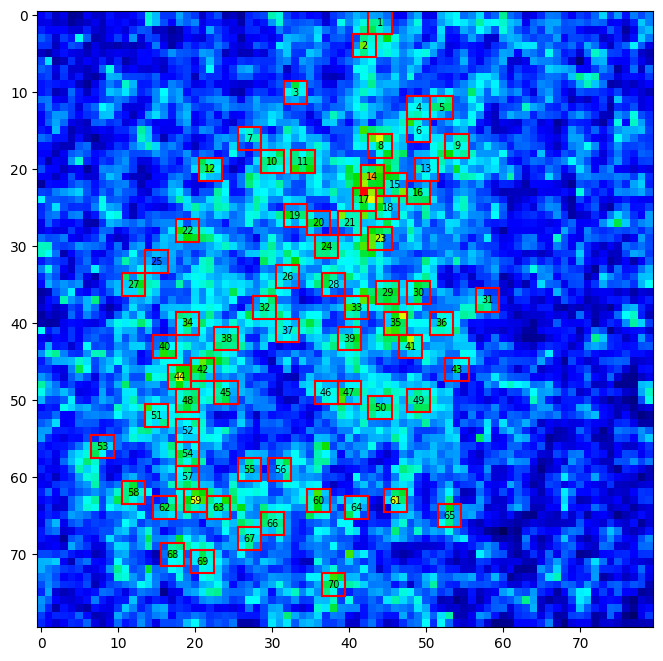

In [13]:
# Plotting.
linewidth = 1.5
color = 'red'

index = np.where(identified_map == 1)
index = np.transpose(index, (1, 0))

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=Maps.colorbar())

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

plt.show()

Neuron 1 and Neuron 9 are correlated with a positive slope, and the P-Value is: 3.3e-05 , distance is: 113.20777358467925 um.
Neuron 1 and Neuron 21 are correlated with a positive slope, and the P-Value is: 0.028644 , distance is: 157.83535725559085 um.
Neuron 1 and Neuron 42 are correlated with a positive slope, and the P-Value is: 0.048136 , distance is: 303.2226904438387 um.
Neuron 2 and Neuron 19 are correlated with a positive slope, and the P-Value is: 0.031373 , distance is: 142.61837188805657 um.
Neuron 2 and Neuron 28 are correlated with a positive slope, and the P-Value is: 0.01315 , distance is: 187.5419952970534 um.
Neuron 3 and Neuron 30 are correlated with a positive slope, and the P-Value is: 0.0 , distance is: 183.17205026968497 um.
Neuron 4 and Neuron 18 are correlated with a positive slope, and the P-Value is: 0.018958 , distance is: 81.60882305241266 um.
Neuron 4 and Neuron 38 are correlated with a positive slope, and the P-Value is: 0.008178 , distance is: 234.307490

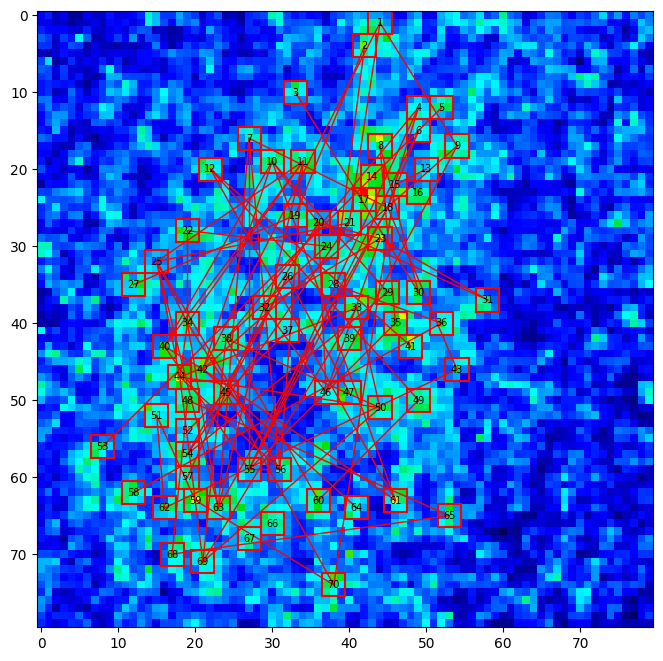

92 pairs are correlated.
Totally 2415 pairs.


In [14]:
num = len(index)
trial = Data.shape[0]
latency = np.zeros((num, trial))
connection = np.zeros(num, dtype=int)
count = 0

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=Maps.colorbar())

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

for i in range(num):
    for j in range(trial):

        Trace = np.mean(Data[j, index[i][0]-1:index[i][0]+2, index[i][1]-1:index[i][1]+2, :], axis=(0, 1))
        latency[i][j] = Maps.Half_Amp_Latency(Trace=Trace, startPt=startPt, numPt=numPt)

for i in range(num-1):
    for j in range(i+1, num):
        
        dist = np.sqrt((index[i][0] - index[j][0])**2 + (index[i][1] - index[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index[i]
            loc_2 = index[j]
            connection[i] = connection[i] + 1
            connection[j] = connection[j] + 1
            ax.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

plt.show()

print(count, 'pairs are correlated.')
print('Totally', int(num*(num-1)/2), 'pairs.')

Neuron 4 and Neuron 18 are correlated with a positive slope, and the P-Value is: 0.018958 , distance is: 81.60882305241266 um.
Neuron 4 and Neuron 38 are correlated with a positive slope, and the P-Value is: 0.008178 , distance is: 234.30749027719963 um.
Neuron 4 and Neuron 55 are correlated with a positive slope, and the P-Value is: 0.04062 , distance is: 311.3647378878989 um.


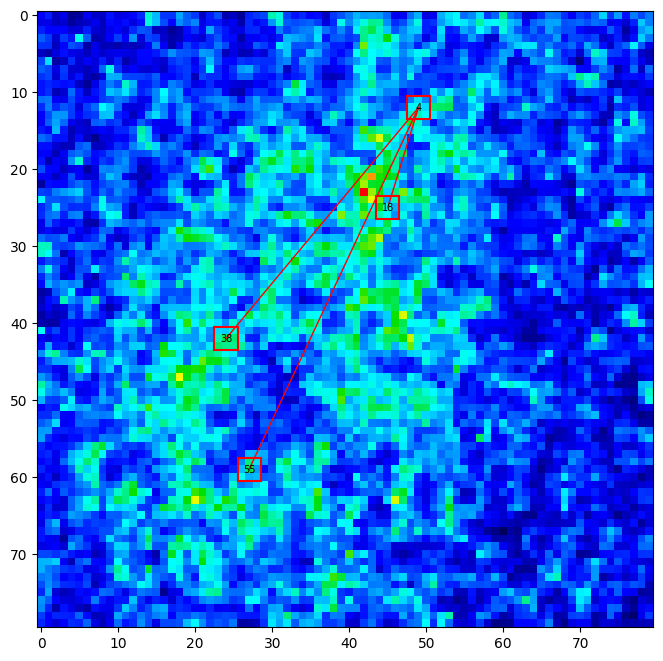

In [15]:
neuro_label = 4

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=Maps.colorbar())
top = index[neuro_label-1][1] - 1.5
bottom = index[neuro_label-1][1] + 1.5
left = index[neuro_label-1][0] - 1.5
right = index[neuro_label-1][0] + 1.5

ax.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax.annotate(str(neuro_label), xy=(index[neuro_label-1][1], index[neuro_label-1][0]), ha='center', va='center', fontsize=7, color='black')

for i in range(num):

    if i == neuro_label - 1:
        continue
    else:
        dist = np.sqrt((index[i][0] - index[neuro_label-1][0])**2 + (index[i][1] - index[neuro_label-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[neuro_label-1])

        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', neuro_label, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index[i]
            loc_2 = index[neuro_label-1]

            ax.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

plt.show()
        

In [17]:

with open('C:/Users/txu245/Desktop/26-02-24/01_01_03_latency.dat', 'a') as f:
    for coor in latency:
        line = '[' + ' '.join(map(str,coor)) + ']'
        f.write(line + '\n')
